# Entity Binding with Distributed Alignment Search

This notebook is a standalone, end-to-end DAS experiment for an entity-binding task.

The task is deliberately synthetic:

```text
Context:
Alice has the apple.
Bob has the chair.
Carol has the stone.
Dave has the ring.
Question: What does Alice have?
Answer:
```

The model should answer `apple`. We then construct counterfactual pairs where the queried entity stays fixed, but the value bound to that entity changes. If the base prompt says `Alice -> apple` and the source prompt says `Alice -> ring`, then an intervention that swaps the model's representation of the causal variable `value_bound_to_queried_entity` should make the base run answer `ring`.

The main result we want is not just "patching can change the answer." Full-vector patching often changes too much. The question is whether DAS can find a lower-dimensional rotated subspace that is causally sufficient for the bound value while leaving the complement less causally active.

References used for the design:

- Distributed Alignment Search: [Geiger et al., 2023](https://arxiv.org/abs/2303.02536)
- RAVEL / MDAS evaluation logic: [Huang et al., 2024](https://arxiv.org/abs/2402.17700), [RAVEL GitHub](https://github.com/explanare/ravel)
- Entity binding in context: [Feng and Steinhardt, 2023](https://arxiv.org/abs/2310.17191)
- Binding and retrieval mechanisms: [Gur-Arieh, Geva, and Geiger, 2026](https://arxiv.org/abs/2510.06182), [project blog](https://yoav.ml/blog/2025/mixing-mechs/)
- Binding subspaces for latent world states: [Feng, Russell, and Steinhardt, 2024](https://arxiv.org/abs/2406.19501)


## 0. What this notebook will show

We will run the whole pipeline:

1. Build a clean counterfactual dataset for an entity-binding variable.
2. Check that the language model can solve the base task under a candidate-answer metric.
3. Run a full-vector activation-patching baseline over layers and semantic token sites.
4. Train a DAS rotation at the best site.
5. Evaluate on held-out counterfactuals with cause, complement-isolate, identity, random-rotation, and subspace-size controls.

The interpretable claim we are testing is:

> A compact rotated subspace at some transformer site carries the value bound to the queried entity.

The evidence is strongest when:

- full-vector patching identifies a plausible site;
- DAS cause accuracy is high on held-out pairs;
- complement patching is low, meaning the target information is not mostly outside the learned subspace;
- identity/random subspace controls are worse than the trained DAS rotation;
- a dimension sweep shows a meaningful accuracy curve rather than a one-off result.


## 1. Install dependencies

This notebook avoids `pyvene` so the intervention mechanics are transparent. We implement DAS directly with Hugging Face forward hooks:

- collect source activations;
- replace a selected rotated subspace in the base activation;
- optimize an orthonormal rotation matrix with gradient descent.

Run this install cell on Colab. If your runtime already has these packages, it should finish quickly.


In [1]:
%pip -q install transformers accelerate sentencepiece einops tqdm pandas matplotlib seaborn


## 2. Imports, configuration, and reproducibility

The default model is `Qwen/Qwen2.5-0.5B`, which is open, small enough for Colab, and usually strong enough for this controlled copying task. On an L4 or A100, you can increase the training and evaluation sizes.

The notebook uses a candidate-answer metric: at the answer position, we compare logits only over the finite set of possible item tokens. This avoids penalizing the model for formatting tokens while still asking whether its internal state favors the correct bound value.


In [2]:
import gc
import math
import random
from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer


SEED = 13
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_NAME = "Qwen/Qwen2.5-0.5B"

# Colab L4/A100 settings. Set QUICK_MODE = True for a fast smoke test.
QUICK_MODE = False
MAX_FILTER_ATTEMPTS = 5000 if not QUICK_MODE else 600
N_TRAIN = 96 if not QUICK_MODE else 24
N_EVAL = 64 if not QUICK_MODE else 16
N_SWEEP = 36 if not QUICK_MODE else 8
DAS_EPOCHS = 10 if not QUICK_MODE else 2
DAS_LR = 1e-3
DAS_K = 32
DIM_SWEEP = [4, 8, 16, 32, 64]
DIM_SWEEP_EPOCHS = 5 if not QUICK_MODE else 1

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if DEVICE == "cuda" else torch.float32

print(f"device={DEVICE}, dtype={DTYPE}, quick_mode={QUICK_MODE}")
if DEVICE == "cpu":
    print("WARNING: no GPU detected. In Colab, use Runtime -> Change runtime type -> GPU before running the full notebook.")


device=cuda, dtype=torch.bfloat16, quick_mode=False


## 3. Load the model

We use the raw causal LM, not a chat template. The task is next-token classification among candidate item tokens. If Colab asks you to restart after installs, restart and continue from here.

If you want to try a larger model later, replace `MODEL_NAME` with an open instruct or base model that fits your Colab runtime. The rest of the notebook is model-agnostic as long as the model exposes `model.model.layers`, which Qwen/Llama/Gemma-style decoder models do.


In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=DTYPE,
    device_map="auto" if DEVICE == "cuda" else None,
)
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

layers = model.model.layers
N_LAYERS = len(layers)
HID = model.config.hidden_size
print(f"loaded {MODEL_NAME}: layers={N_LAYERS}, hidden_size={HID}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

loaded Qwen/Qwen2.5-0.5B: layers=24, hidden_size=896


## 4. Define the high-level causal model

The high-level model is a small deterministic program:

- inputs: a list of entity-value bindings and a queried entity;
- variable of interest: `bound_value = bindings[queried_entity]`;
- output: `bound_value`.

The counterfactual intervention is an interchange intervention on `bound_value`. We take the value from a source prompt and inject the corresponding neural representation into the base prompt. If the neural site really represents this variable, the base output should switch to the source value.

This is close to the entity-binding literature because the model must use in-context information rather than a memorized factual association. It is also clean enough that every counterfactual label is generated by an explicit causal model.


In [4]:
NAMES_RAW = [
    "Alice", "Bob", "Carol", "Dave", "Eve", "Frank", "Grace", "Henry",
    "Irene", "Jack", "Kate", "Liam", "Mia", "Nora", "Oscar", "Paul",
    "Quinn", "Rose", "Sam", "Tina", "Uma", "Vera", "Will", "Zoe",
]

ITEMS_RAW = [
    "apple", "chair", "stone", "ring", "book", "cup", "lamp", "coin",
    "key", "rope", "shell", "map", "drum", "glass", "brush", "card",
    "bell", "clock", "spoon", "hat", "bag", "pen", "bowl", "scarf",
    "candle", "button", "leaf", "jar", "shoe", "ticket", "fork", "plate",
]


def one_token_with_leading_space(word: str) -> bool:
    ids = tokenizer.encode(" " + word, add_special_tokens=False)
    return len(ids) == 1


NAMES = [x for x in NAMES_RAW if one_token_with_leading_space(x)]
ITEMS = [x for x in ITEMS_RAW if one_token_with_leading_space(x)]

print(f"single-token names: {len(NAMES)} / {len(NAMES_RAW)}")
print(f"single-token items: {len(ITEMS)} / {len(ITEMS_RAW)}")
print("names:", NAMES[:12])
print("items:", ITEMS[:16])

assert len(NAMES) >= 12, "Need enough single-token names. Try another model or edit NAMES_RAW."
assert len(ITEMS) >= 16, "Need enough single-token items. Try another model or edit ITEMS_RAW."

ITEM_TOKEN_IDS = [tokenizer.encode(" " + item, add_special_tokens=False)[0] for item in ITEMS]
ITEM_TO_CANDIDATE_INDEX = {item: i for i, item in enumerate(ITEMS)}
ITEM_TO_TOKEN_ID = dict(zip(ITEMS, ITEM_TOKEN_IDS))

assert len(set(ITEM_TOKEN_IDS)) == len(ITEM_TOKEN_IDS), "Candidate items must map to unique token ids."


single-token names: 24 / 24
single-token items: 32 / 32
names: ['Alice', 'Bob', 'Carol', 'Dave', 'Eve', 'Frank', 'Grace', 'Henry', 'Irene', 'Jack', 'Kate', 'Liam']
items: ['apple', 'chair', 'stone', 'ring', 'book', 'cup', 'lamp', 'coin', 'key', 'rope', 'shell', 'map', 'drum', 'glass', 'brush', 'card']


## 5. Prompt format and semantic token sites

We will intervene at semantic sites rather than arbitrary absolute positions:

- `queried_value`: the item token in the context line for the queried entity;
- `query_entity`: the entity token in the question;
- `final_token`: the final token before the answer is predicted.

The full-vector patching sweep will decide which layer and site is best. DAS will then learn a rotated subspace at that site.

The code below also records token positions using tokenizer offset mappings, so the notebook remains readable even if tokenization changes slightly across models.


In [5]:
@dataclass
class BindingExample:
    base_prompt: str
    source_prompt: str
    query: str
    base_value: str
    source_value: str
    base_bindings: Dict[str, str]
    source_bindings: Dict[str, str]
    base_positions: Dict[str, int]
    source_positions: Dict[str, int]


def render_prompt(bindings: Dict[str, str], query: str) -> str:
    lines = ["Context:"]
    for entity, value in bindings.items():
        lines.append(f"{entity} has the {value}.")
    lines.append(f"Question: What does {query} have?")
    lines.append("Answer:")
    return "\n".join(lines)


def token_offsets(prompt: str):
    enc = tokenizer(prompt, return_offsets_mapping=True, add_special_tokens=False)
    return enc["input_ids"], enc["offset_mapping"]


def find_token_at_text(prompt: str, text: str, occurrence: int = 0) -> int:
    start = -1
    search_from = 0
    for _ in range(occurrence + 1):
        start = prompt.find(text, search_from)
        if start == -1:
            raise ValueError(f"Could not find {text!r} occurrence {occurrence} in prompt.")
        search_from = start + len(text)
    end = start + len(text)
    _, offsets = token_offsets(prompt)
    overlapping = [i for i, (a, b) in enumerate(offsets) if a < end and b > start]
    if not overlapping:
        raise ValueError(f"No token overlaps {text!r}.")
    return overlapping[-1]


def semantic_positions(prompt: str, query: str, value: str, bindings: Dict[str, str]) -> Dict[str, int]:
    # Query appears once in context and once in the question if it is the first mention.
    # We want the question mention, so use the last occurrence.
    query_count_before_question = prompt[: prompt.rfind("Question:")].count(query)
    query_entity_pos = find_token_at_text(prompt, query, occurrence=query_count_before_question)

    fact_line = f"{query} has the {value}."
    fact_start = prompt.find(fact_line)
    if fact_start == -1:
        raise ValueError(f"Could not find queried fact line: {fact_line}")
    value_start_text = prompt[fact_start:].find(value)
    value_occurrence = prompt[: fact_start + value_start_text].count(value)
    queried_value_pos = find_token_at_text(prompt, value, occurrence=value_occurrence)

    input_ids, _ = token_offsets(prompt)
    return {
        "queried_value": queried_value_pos,
        "query_entity": query_entity_pos,
        "final_token": len(input_ids) - 1,
    }


def classify_prompt(prompt: str) -> Tuple[str, torch.Tensor]:
    input_ids = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).input_ids.to(model.device)
    with torch.no_grad():
        logits = model(input_ids).logits[0, -1]
    candidate_logits = logits[ITEM_TOKEN_IDS]
    pred_idx = int(candidate_logits.argmax().item())
    return ITEMS[pred_idx], candidate_logits.detach().float().cpu()


## 6. Construct counterfactual pairs

Each example has:

- a base prompt;
- a source prompt with the same entities and query;
- exactly one changed binding: the value attached to the queried entity.

This gives a clean interchange target. The base high-level output is the base value; the counterfactual high-level output is the source value.

We also filter to examples where the model gets both the base and source prompts right under the candidate-answer metric. This matters: if the model does not solve the ordinary task, a failed intervention would not be interpretable.


In [6]:
def make_candidate_example(rng: random.Random, n_bindings: int = 4) -> BindingExample:
    entities = rng.sample(NAMES, n_bindings)
    values = rng.sample(ITEMS, n_bindings + 1)
    query_idx = rng.randrange(n_bindings)
    query = entities[query_idx]

    base_values = values[:n_bindings]
    source_values = list(base_values)
    source_values[query_idx] = values[-1]

    base_bindings = dict(zip(entities, base_values))
    source_bindings = dict(zip(entities, source_values))
    base_prompt = render_prompt(base_bindings, query)
    source_prompt = render_prompt(source_bindings, query)

    base_ids = tokenizer(base_prompt, add_special_tokens=False).input_ids
    source_ids = tokenizer(source_prompt, add_special_tokens=False).input_ids
    if len(base_ids) != len(source_ids):
        raise ValueError("Base/source token lengths differ; choose different words or model.")

    return BindingExample(
        base_prompt=base_prompt,
        source_prompt=source_prompt,
        query=query,
        base_value=base_bindings[query],
        source_value=source_bindings[query],
        base_bindings=base_bindings,
        source_bindings=source_bindings,
        base_positions=semantic_positions(base_prompt, query, base_bindings[query], base_bindings),
        source_positions=semantic_positions(source_prompt, query, source_bindings[query], source_bindings),
    )


def build_filtered_dataset(n_keep: int, seed: int = SEED) -> List[BindingExample]:
    rng = random.Random(seed)
    kept = []
    seen = set()
    attempts = 0
    pbar = tqdm(total=n_keep, desc="filtering model-correct pairs")
    while len(kept) < n_keep and attempts < MAX_FILTER_ATTEMPTS:
        attempts += 1
        try:
            ex = make_candidate_example(rng)
        except ValueError:
            continue
        key = (ex.base_prompt, ex.source_prompt)
        if key in seen:
            continue
        seen.add(key)

        base_pred, _ = classify_prompt(ex.base_prompt)
        source_pred, _ = classify_prompt(ex.source_prompt)
        if base_pred == ex.base_value and source_pred == ex.source_value:
            kept.append(ex)
            pbar.update(1)
    pbar.close()
    print(f"kept {len(kept)} examples after {attempts} attempts")
    if len(kept) < n_keep:
        raise RuntimeError(
            f"Not enough model-correct examples: kept {len(kept)} / {n_keep} after {attempts} attempts. "
            "Increase MAX_FILTER_ATTEMPTS, set QUICK_MODE=True, or use a stronger model."
        )
    return kept


all_examples = build_filtered_dataset(N_TRAIN + N_EVAL + N_SWEEP)
rng = random.Random(SEED)
rng.shuffle(all_examples)

sweep_examples = all_examples[:N_SWEEP]
train_examples = all_examples[N_SWEEP : N_SWEEP + N_TRAIN]
eval_examples = all_examples[N_SWEEP + N_TRAIN :]

print(len(sweep_examples), len(train_examples), len(eval_examples))
print("\nExample base prompt:\n", train_examples[0].base_prompt)
print("\nExample source prompt:\n", train_examples[0].source_prompt)
print("base/source answer:", train_examples[0].base_value, "->", train_examples[0].source_value)
print("semantic positions:", train_examples[0].base_positions)


filtering model-correct pairs:   0%|          | 0/196 [00:00<?, ?it/s]

kept 196 examples after 748 attempts
36 96 64

Example base prompt:
 Context:
Rose has the leaf.
Zoe has the cup.
Liam has the glass.
Carol has the pen.
Question: What does Rose have?
Answer:

Example source prompt:
 Context:
Rose has the rope.
Zoe has the cup.
Liam has the glass.
Carol has the pen.
Question: What does Rose have?
Answer:
base/source answer: leaf -> rope
semantic positions: {'queried_value': 5, 'query_entity': 28, 'final_token': 32}


## 7. Activation collection and intervention helpers

The next functions are the core mechanics.

`collect_activations` runs a prompt once and stores each layer's output residual stream. `forward_with_site_patch` reruns the base prompt and replaces a selected activation vector with a transformed version. Full-vector patching sets the base vector equal to the source vector. DAS patching will replace only the first `k` dimensions after rotating into a learned basis.


In [7]:
def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


@torch.no_grad()
def collect_activations(prompt: str) -> List[torch.Tensor]:
    cache = [None for _ in range(N_LAYERS)]
    handles = []

    def make_hook(layer_idx):
        def hook(module, inputs, output):
            hidden = output[0] if isinstance(output, tuple) else output
            cache[layer_idx] = hidden.detach().float().cpu()
        return hook

    for i, layer in enumerate(layers):
        handles.append(layer.register_forward_hook(make_hook(i)))
    input_ids = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).input_ids.to(model.device)
    _ = model(input_ids)
    for h in handles:
        h.remove()
    return cache


def get_prompt_cache(examples: List[BindingExample]) -> Dict[str, List[torch.Tensor]]:
    prompts = sorted({ex.base_prompt for ex in examples} | {ex.source_prompt for ex in examples})
    cache = {}
    for prompt in tqdm(prompts, desc="collecting activations"):
        cache[prompt] = collect_activations(prompt)
    return cache


def forward_with_site_patch(
    prompt: str,
    layer_idx: int,
    base_pos: int,
    transform_fn: Callable[[torch.Tensor], torch.Tensor],
) -> torch.Tensor:
    def hook(module, inputs, output):
        hidden = output[0] if isinstance(output, tuple) else output
        hidden = hidden.clone()
        replacement = transform_fn(hidden[:, base_pos, :])
        hidden[:, base_pos, :] = replacement.to(hidden.dtype)
        if isinstance(output, tuple):
            return (hidden,) + output[1:]
        return hidden

    handle = layers[layer_idx].register_forward_hook(hook)
    try:
        input_ids = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).input_ids.to(model.device)
        logits = model(input_ids).logits[:, -1, :]
    finally:
        handle.remove()
    return logits


def candidate_prediction_from_logits(logits: torch.Tensor) -> str:
    candidate_logits = logits[0, ITEM_TOKEN_IDS]
    return ITEMS[int(candidate_logits.argmax().item())]


def target_index(item: str) -> torch.Tensor:
    return torch.tensor([ITEM_TO_CANDIDATE_INDEX[item]], device=model.device)


## 8. Full-vector activation patching baseline

Full-vector patching asks: if we overwrite the entire activation vector at a layer/site with the source activation, does the base answer switch to the source value?

This is a coarse localization baseline. It is useful because it tells us where causal information is likely to flow, but it does not isolate a feature. If full-vector patching works and DAS later works with a smaller subspace, then the DAS result is more interpretable.


collecting activations:   0%|          | 0/72 [00:00<?, ?it/s]

full-vector patch sweep:   0%|          | 0/24 [00:00<?, ?it/s]

Best full-vector cause IIA: layer=0, site=queried_value, acc=1.000


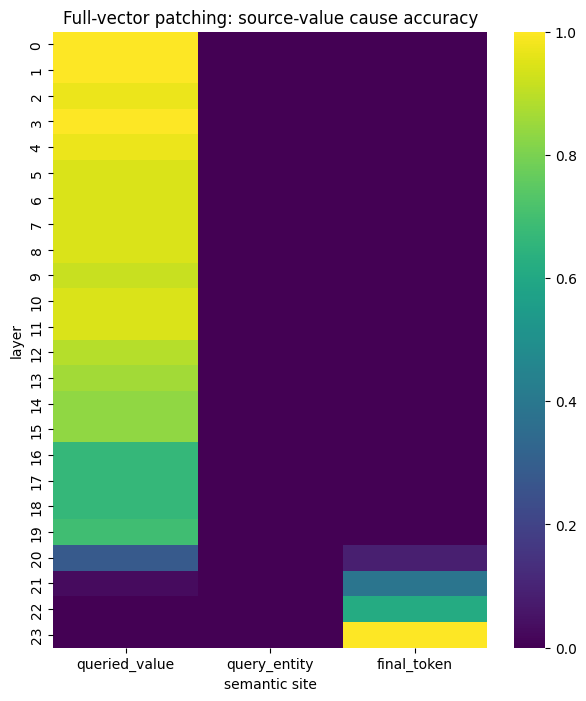

In [8]:
sweep_cache = get_prompt_cache(sweep_examples)
SITES = ["queried_value", "query_entity", "final_token"]


def full_vector_patch_accuracy(
    examples: List[BindingExample],
    cache: Dict[str, List[torch.Tensor]],
    layer_idx: int,
    site: str,
    target: str = "source",
) -> float:
    correct = 0
    for ex in examples:
        source_pos = ex.source_positions[site]
        base_pos = ex.base_positions[site]
        src_h = cache[ex.source_prompt][layer_idx][0, source_pos, :].to(model.device)

        logits = forward_with_site_patch(
            ex.base_prompt,
            layer_idx,
            base_pos,
            transform_fn=lambda h, src_h=src_h: src_h.unsqueeze(0).to(h.device),
        )
        pred = candidate_prediction_from_logits(logits)
        wanted = ex.source_value if target == "source" else ex.base_value
        correct += int(pred == wanted)
    return correct / len(examples)


full_patch_grid = np.zeros((N_LAYERS, len(SITES)))
for layer_idx in tqdm(range(N_LAYERS), desc="full-vector patch sweep"):
    for site_idx, site in enumerate(SITES):
        full_patch_grid[layer_idx, site_idx] = full_vector_patch_accuracy(
            sweep_examples, sweep_cache, layer_idx, site, target="source"
        )

best_flat = int(full_patch_grid.argmax())
BEST_LAYER, BEST_SITE_IDX = np.unravel_index(best_flat, full_patch_grid.shape)
BEST_SITE = SITES[BEST_SITE_IDX]

print(f"Best full-vector cause IIA: layer={BEST_LAYER}, site={BEST_SITE}, acc={full_patch_grid[BEST_LAYER, BEST_SITE_IDX]:.3f}")

plt.figure(figsize=(7, 8))
sns.heatmap(
    full_patch_grid,
    cmap="viridis",
    vmin=0,
    vmax=1,
    xticklabels=SITES,
    yticklabels=list(range(N_LAYERS)),
)
plt.xlabel("semantic site")
plt.ylabel("layer")
plt.title("Full-vector patching: source-value cause accuracy")
plt.show()


## 9. Evaluate the baseline on held-out pairs

The sweep used a small set to choose a site. Now we compute held-out full-vector patching at that site. This is the baseline DAS must be compared against.

Interpretation:

- high held-out full-vector cause accuracy means the selected site is causally relevant;
- it does not by itself tell us whether the information is cleanly isolated.


In [9]:
eval_cache = get_prompt_cache(eval_examples)
train_cache = get_prompt_cache(train_examples)

heldout_full_cause = full_vector_patch_accuracy(
    eval_examples, eval_cache, BEST_LAYER, BEST_SITE, target="source"
)
print(f"Held-out full-vector cause IIA at layer={BEST_LAYER}, site={BEST_SITE}: {heldout_full_cause:.3f}")


collecting activations:   0%|          | 0/128 [00:00<?, ?it/s]

collecting activations:   0%|          | 0/192 [00:00<?, ?it/s]

Held-out full-vector cause IIA at layer=0, site=queried_value: 1.000


## 10. DAS parameterization

DAS learns an orthonormal rotation matrix `R`.

For a base activation `h_b` and source activation `h_s`:

1. rotate both into the DAS basis: `z_b = h_b R`, `z_s = h_s R`;
2. replace the first `k` rotated coordinates of the base with the source;
3. rotate back to the model basis.

If the first `k` rotated dimensions align with the high-level variable `value_bound_to_queried_entity`, then this subspace patch should make the base prompt answer with the source value.

We optimize only `R`. The language model weights stay frozen.


In [10]:
def project_orthonormal(R: torch.Tensor) -> torch.Tensor:
    # QR projection keeps the learned basis orthonormal.
    Q, _ = torch.linalg.qr(R)
    return Q


def das_transform(h_base: torch.Tensor, h_source: torch.Tensor, R_orth: torch.Tensor, k: int, mode: str) -> torch.Tensor:
    z_base = h_base.float() @ R_orth
    z_source = h_source.float() @ R_orth
    z_new = z_base.clone()
    if mode == "cause":
        z_new[:, :k] = z_source[:, :k]
    elif mode == "complement":
        z_new[:, k:] = z_source[:, k:]
    elif mode == "full_rotated":
        z_new[:, :] = z_source[:, :]
    else:
        raise ValueError(f"unknown mode: {mode}")
    return z_new @ R_orth.T


def train_das_rotation(
    examples: List[BindingExample],
    cache: Dict[str, List[torch.Tensor]],
    layer_idx: int,
    site: str,
    k: int,
    epochs: int,
    lr: float = DAS_LR,
) -> torch.Tensor:
    R = torch.eye(HID, device=model.device, dtype=torch.float32, requires_grad=True)
    opt = torch.optim.Adam([R], lr=lr)
    order_rng = random.Random(SEED)

    for epoch in range(epochs):
        shuffled = list(examples)
        order_rng.shuffle(shuffled)
        losses = []
        correct = 0

        for ex in tqdm(shuffled, desc=f"DAS epoch {epoch+1}/{epochs}", leave=False):
            source_pos = ex.source_positions[site]
            base_pos = ex.base_positions[site]
            src_h = cache[ex.source_prompt][layer_idx][0, source_pos, :].to(model.device).unsqueeze(0)
            R_orth = project_orthonormal(R)

            logits = forward_with_site_patch(
                ex.base_prompt,
                layer_idx,
                base_pos,
                transform_fn=lambda h, src_h=src_h, R_orth=R_orth: das_transform(h, src_h, R_orth, k, "cause"),
            )
            candidate_logits = logits[:, ITEM_TOKEN_IDS]
            loss = F.cross_entropy(candidate_logits.float(), target_index(ex.source_value))

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_([R], 1.0)
            opt.step()

            losses.append(float(loss.detach().cpu()))
            pred = ITEMS[int(candidate_logits.detach().argmax(dim=-1).item())]
            correct += int(pred == ex.source_value)

        with torch.no_grad():
            R.copy_(project_orthonormal(R))
        print(f"epoch {epoch+1:02d}: loss={np.mean(losses):.4f}, train-cause-acc={correct/len(examples):.3f}")

    return project_orthonormal(R.detach()).cpu()


## 11. Train DAS at the best patching site

This cell learns the rotation. The site was selected by full-vector patching, but the rotation is trained only on the training examples and evaluated later on held-out examples.

If this cell is slow on an L4, set `QUICK_MODE = True` near the top for a smoke test, or reduce `N_TRAIN` and `DAS_EPOCHS`.


In [11]:
clear_memory()
R_DAS = train_das_rotation(
    train_examples,
    train_cache,
    layer_idx=BEST_LAYER,
    site=BEST_SITE,
    k=DAS_K,
    epochs=DAS_EPOCHS,
    lr=DAS_LR,
)
clear_memory()


DAS epoch 1/10:   0%|          | 0/96 [00:00<?, ?it/s]

epoch 01: loss=6.3124, train-cause-acc=0.000


DAS epoch 2/10:   0%|          | 0/96 [00:00<?, ?it/s]

epoch 02: loss=4.2550, train-cause-acc=0.031


DAS epoch 3/10:   0%|          | 0/96 [00:00<?, ?it/s]

...

epoch 08: loss=0.0999, train-cause-acc=0.990


DAS epoch 9/10:   0%|          | 0/96 [00:00<?, ?it/s]

epoch 09: loss=0.0701, train-cause-acc=1.000


DAS epoch 10/10:   0%|          | 0/96 [00:00<?, ?it/s]

epoch 10: loss=0.0446, train-cause-acc=0.990


## 12. Held-out DAS evaluation

We now evaluate four interventions on held-out examples:

- `das_cause`: patch only the learned first `k` dimensions; desired answer is the source value.
- `das_complement`: patch all dimensions except the first `k`; desired answer is the base value. Lower leakage through the complement is better.
- `identity_cause`: use the first `k` raw coordinates without a learned rotation.
- `random_cause`: use random orthonormal rotations as controls.

The cleanest result is: high `das_cause`, high `das_complement_keep_base`, and substantially lower identity/random cause accuracy.


eval cause:   0%|          | 0/64 [00:00<?, ?it/s]

eval complement:   0%|          | 0/64 [00:00<?, ?it/s]

eval cause:   0%|          | 0/64 [00:00<?, ?it/s]

eval cause:   0%|          | 0/64 [00:00<?, ?it/s]

eval cause:   0%|          | 0/64 [00:00<?, ?it/s]

eval cause:   0%|          | 0/64 [00:00<?, ?it/s]

                       metric  accuracy
            full_vector_cause  1.000000
               das_cause_k=32  0.546875
das_complement_keep_base_k=32  0.531250
          identity_cause_k=32  0.000000
       random_cause_k=32_mean  0.000000
random cause scores: [0.0, 0.0, 0.0]


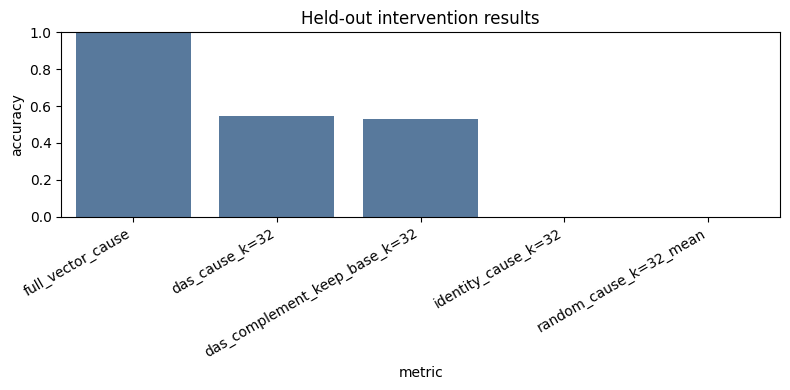

In [12]:
@torch.no_grad()
def evaluate_subspace_intervention(
    R_cpu: torch.Tensor,
    examples: List[BindingExample],
    cache: Dict[str, List[torch.Tensor]],
    layer_idx: int,
    site: str,
    k: int,
    mode: str,
) -> float:
    R_orth = R_cpu.to(model.device)
    correct = 0
    for ex in tqdm(examples, desc=f"eval {mode}", leave=False):
        source_pos = ex.source_positions[site]
        base_pos = ex.base_positions[site]
        src_h = cache[ex.source_prompt][layer_idx][0, source_pos, :].to(model.device).unsqueeze(0)
        logits = forward_with_site_patch(
            ex.base_prompt,
            layer_idx,
            base_pos,
            transform_fn=lambda h, src_h=src_h, R_orth=R_orth: das_transform(h, src_h, R_orth, k, mode),
        )
        pred = candidate_prediction_from_logits(logits)
        wanted = ex.source_value if mode in ("cause", "full_rotated") else ex.base_value
        correct += int(pred == wanted)
    return correct / len(examples)


def random_orthonormal(seed: int) -> torch.Tensor:
    gen = torch.Generator(device="cpu").manual_seed(seed)
    A = torch.randn(HID, HID, generator=gen)
    Q, _ = torch.linalg.qr(A)
    return Q


R_ID = torch.eye(HID)
das_cause = evaluate_subspace_intervention(R_DAS, eval_examples, eval_cache, BEST_LAYER, BEST_SITE, DAS_K, "cause")
das_complement_keep_base = evaluate_subspace_intervention(R_DAS, eval_examples, eval_cache, BEST_LAYER, BEST_SITE, DAS_K, "complement")
identity_cause = evaluate_subspace_intervention(R_ID, eval_examples, eval_cache, BEST_LAYER, BEST_SITE, DAS_K, "cause")

random_scores = []
for s in [101, 102, 103]:
    R_rand = random_orthonormal(s)
    random_scores.append(evaluate_subspace_intervention(R_rand, eval_examples, eval_cache, BEST_LAYER, BEST_SITE, DAS_K, "cause"))

results = pd.DataFrame(
    [
        {"metric": "full_vector_cause", "accuracy": heldout_full_cause},
        {"metric": f"das_cause_k={DAS_K}", "accuracy": das_cause},
        {"metric": f"das_complement_keep_base_k={DAS_K}", "accuracy": das_complement_keep_base},
        {"metric": f"identity_cause_k={DAS_K}", "accuracy": identity_cause},
        {"metric": f"random_cause_k={DAS_K}_mean", "accuracy": float(np.mean(random_scores))},
    ]
)

print(results.to_string(index=False))
print("random cause scores:", [round(x, 3) for x in random_scores])

plt.figure(figsize=(8, 4))
sns.barplot(data=results, x="metric", y="accuracy", color="#4C78A8")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.title("Held-out intervention results")
plt.tight_layout()
plt.show()


## 13. Subspace dimension sweep

A single `k` can be misleading. The sweep below retrains DAS for several subspace sizes.

Expected pattern:

- very small `k` may be too weak;
- moderate `k` should improve cause accuracy;
- if very large `k` improves cause but hurts complement isolation, the variable is not cleanly isolated at that size.

This is useful for the final writeup because it turns the claim from "we got one number" into "we observed a capacity/specificity tradeoff."



Training DAS dimension sweep k=4


DAS epoch 1/5:   0%|          | 0/96 [00:00<?, ?it/s]

epoch 01: loss=6.8761, train-cause-acc=0.000


DAS epoch 2/5:   0%|          | 0/96 [00:00<?, ?it/s]

epoch 02: loss=6.3696, train-cause-acc=0.000


...

DAS epoch 5/5:   0%|          | 0/96 [00:00<?, ?it/s]

epoch 05: loss=0.2348, train-cause-acc=0.958


eval cause:   0%|          | 0/64 [00:00<?, ?it/s]

eval complement:   0%|          | 0/64 [00:00<?, ?it/s]

 k    cause  complement_keep_base
 4 0.015625              0.000000
 8 0.109375              0.046875
16 0.218750              0.187500
32 0.390625              0.375000
64 0.546875              0.484375


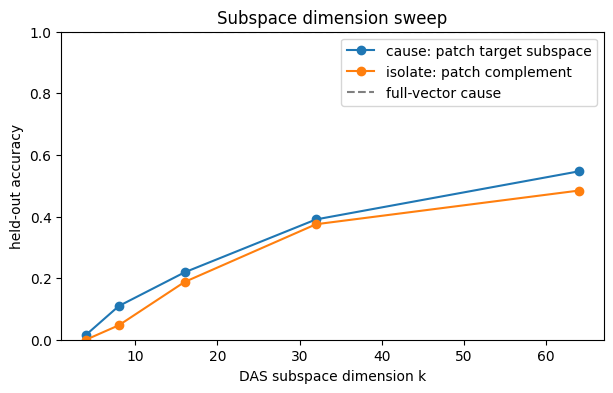

In [13]:
dim_rows = []
for k in DIM_SWEEP:
    if k >= HID:
        continue
    print(f"\nTraining DAS dimension sweep k={k}")
    R_k = train_das_rotation(
        train_examples,
        train_cache,
        layer_idx=BEST_LAYER,
        site=BEST_SITE,
        k=k,
        epochs=DIM_SWEEP_EPOCHS,
        lr=DAS_LR,
    )
    cause_k = evaluate_subspace_intervention(R_k, eval_examples, eval_cache, BEST_LAYER, BEST_SITE, k, "cause")
    comp_k = evaluate_subspace_intervention(R_k, eval_examples, eval_cache, BEST_LAYER, BEST_SITE, k, "complement")
    dim_rows.append({"k": k, "cause": cause_k, "complement_keep_base": comp_k})
    clear_memory()

dim_results = pd.DataFrame(dim_rows)
print(dim_results.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.plot(dim_results["k"], dim_results["cause"], marker="o", label="cause: patch target subspace")
plt.plot(dim_results["k"], dim_results["complement_keep_base"], marker="o", label="isolate: patch complement")
plt.axhline(heldout_full_cause, linestyle="--", color="gray", label="full-vector cause")
plt.xlabel("DAS subspace dimension k")
plt.ylabel("held-out accuracy")
plt.ylim(0, 1)
plt.title("Subspace dimension sweep")
plt.legend()
plt.show()


## 14. Concrete examples after intervention

Aggregate metrics are necessary, but the task should also be readable. This cell prints a few held-out examples with:

- the base answer;
- the source counterfactual answer;
- the model prediction after DAS cause patching;
- the model prediction after complement patching.

These examples are good material for a presentation because they make the intervention semantics concrete.


In [14]:
def predict_after_subspace(ex: BindingExample, R_cpu: torch.Tensor, mode: str, k: int) -> str:
    R_orth = R_cpu.to(model.device)
    source_pos = ex.source_positions[BEST_SITE]
    base_pos = ex.base_positions[BEST_SITE]
    src_h = eval_cache[ex.source_prompt][BEST_LAYER][0, source_pos, :].to(model.device).unsqueeze(0)
    logits = forward_with_site_patch(
        ex.base_prompt,
        BEST_LAYER,
        base_pos,
        transform_fn=lambda h, src_h=src_h, R_orth=R_orth: das_transform(h, src_h, R_orth, k, mode),
    )
    return candidate_prediction_from_logits(logits)


for i, ex in enumerate(eval_examples[:5]):
    base_pred, _ = classify_prompt(ex.base_prompt)
    source_pred, _ = classify_prompt(ex.source_prompt)
    das_pred = predict_after_subspace(ex, R_DAS, "cause", DAS_K)
    comp_pred = predict_after_subspace(ex, R_DAS, "complement", DAS_K)
    print("=" * 80)
    print(f"example {i}")
    print(ex.base_prompt)
    print(f"base target={ex.base_value}, source target={ex.source_value}")
    print(f"ordinary base pred={base_pred}, ordinary source pred={source_pred}")
    print(f"DAS cause pred={das_pred}; DAS complement pred={comp_pred}")


example 0
Context:
Kate has the spoon.
Bob has the plate.
Jack has the coin.
Henry has the candle.
Question: What does Henry have?
Answer:
base target=candle, source target=apple
ordinary base pred=candle, ordinary source pred=apple
DAS cause pred=apple; DAS complement pred=coin
example 1
Context:
Mia has the bag.
Zoe has the scarf.
Kate has the leaf.
Jack has the coin.
Question: What does Kate have?
Answer:
base target=leaf, source target=button
ordinary base pred=leaf, ordinary source pred=button
DAS cause pred=bag; DAS complement pred=leaf
example 2
Context:
Oscar has the fork.
Dave has the book.
Kate has the brush.
Sam has the chair.
Question: What does Oscar have?
Answer:
base target=fork, source target=spoon
ordinary base pred=fork, ordinary source pred=spoon
DAS cause pred=fork; DAS complement pred=book
example 3
Context:
Oscar has the bell.
Mia has the shell.
Alice has the apple.
Kate has the bowl.
Question: What does Mia have?
Answer:
base target=shell, source target=leaf
ordi

## 15. Automatic takeaways

Use this cell as a first draft of the project takeaway. You should still inspect the heatmap and examples above, but these rules make the interpretation explicit.


In [15]:
print("Selected site")
print(f"- layer: {BEST_LAYER}")
print(f"- semantic site: {BEST_SITE}")
print(f"- full-vector held-out cause IIA: {heldout_full_cause:.3f}")
print()

print("DAS evidence")
print(f"- DAS cause IIA, k={DAS_K}: {das_cause:.3f}")
print(f"- DAS complement keeps base, k={DAS_K}: {das_complement_keep_base:.3f}")
print(f"- identity-subspace cause, k={DAS_K}: {identity_cause:.3f}")
print(f"- random-rotation cause mean, k={DAS_K}: {np.mean(random_scores):.3f}")
print()

if das_cause > identity_cause + 0.10 and das_cause > np.mean(random_scores) + 0.10:
    print("Interpretation: the learned rotation is doing real work beyond choosing raw coordinates or a random basis.")
else:
    print("Interpretation: the learned rotation is not clearly separated from controls; increase data/epochs or revisit the site.")

if das_complement_keep_base >= 0.75:
    print("Isolation: complement patching usually preserves the base answer, so the target subspace is relatively specific.")
else:
    print("Isolation: complement patching often changes the answer, so binding information is still leaking outside the chosen subspace.")

print()
print("Suggested final claim:")
print(
    "On a controlled in-context entity-binding task, full-vector patching localizes a causally relevant "
    f"site at layer {BEST_LAYER}, {BEST_SITE}. DAS learns a {DAS_K}-dimensional rotated subspace that "
    "mediates the value bound to the queried entity on held-out counterfactual pairs, with specificity "
    "assessed by complement patching and random/identity controls."
)


Selected site
- layer: 0
- semantic site: queried_value
- full-vector held-out cause IIA: 1.000

DAS evidence
- DAS cause IIA, k=32: 0.547
- DAS complement keeps base, k=32: 0.531
- identity-subspace cause, k=32: 0.000
- random-rotation cause mean, k=32: 0.000

Interpretation: the learned rotation is doing real work beyond choosing raw coordinates or a random basis.
Isolation: complement patching often changes the answer, so binding information is still leaking outside the chosen subspace.

Suggested final claim:
On a controlled in-context entity-binding task, full-vector patching localizes a causally relevant site at layer 0, queried_value. DAS learns a 32-dimensional rotated subspace that mediates the value bound to the queried entity on held-out counterfactual pairs, with specificity assessed by complement patching and random/identity controls.


## 16. Limitations and next steps

This notebook gives a clean end-to-end result, but the limitations should be stated plainly:

1. The task is synthetic. That is good for causal labels, but it is not a natural benchmark.
2. Candidate-answer accuracy is a controlled metric, not unconstrained generation accuracy.
3. DAS learns a linear subspace at one site. A model may distribute binding across multiple sites or nonlinear features.
4. If complement patching is not high, the result is partial localization rather than a complete causal abstraction.

Natural extensions:

- compare 2, 4, 6, and 8 bindings to see whether the site changes with context length;
- separate positional, lexical, and reflexive mechanisms following the binding-retrieval literature;
- train a multi-task DAS objective that simultaneously causes the queried value and preserves non-queried bindings;
- repeat with a larger open model on A100 for stronger base-task accuracy and cleaner interventions.


## Extension A: binding-load scaling

The first extension asks whether the result changes as the number of bindings grows.

This matters because a real binding mechanism should not only work for four facts. If the model is relying on a shallow lexical copy from the queried value token, full-vector patching may stay strong at early value-token sites even when the prompt gets longer. If the model is doing retrieval at the query/final token, later sites may become more important as binding load increases.

The function below runs a compact end-to-end pipeline for several context lengths:

1. build model-correct counterfactual examples;
2. run full-vector patching over layers and semantic sites;
3. train a small DAS run at the best site;
4. report held-out full-vector, DAS cause, and DAS complement scores.

The defaults are intentionally smaller than the main run so this can fit into limited Colab compute.


filter n_bindings=2:   0%|          | 0/68 [00:00<?, ?it/s]

collecting activations:   0%|          | 0/24 [00:00<?, ?it/s]

sweep n=2:   0%|          | 0/24 [00:00<?, ?it/s]

collecting activations:   0%|          | 0/64 [00:00<?, ?it/s]

collecting activations:   0%|          | 0/48 [00:00<?, ?it/s]

...

DAS epoch 3/3:   0%|          | 0/32 [00:00<?, ?it/s]

epoch 03: loss=2.8583, train-cause-acc=0.312


eval cause:   0%|          | 0/24 [00:00<?, ?it/s]

eval complement:   0%|          | 0/24 [00:00<?, ?it/s]

 n_bindings status  best_layer     best_site  full_vector_cause  das_cause  das_complement_keep_base  k  epochs
          2     ok           0 queried_value           1.000000   0.083333                  0.083333 64       3
          4     ok          23   final_token           1.000000   0.166667                  0.208333 64       3
          6     ok           0 queried_value           1.000000   0.000000                  0.000000 64       3
          8     ok           3 queried_value           0.958333   0.041667                  0.000000 64       3


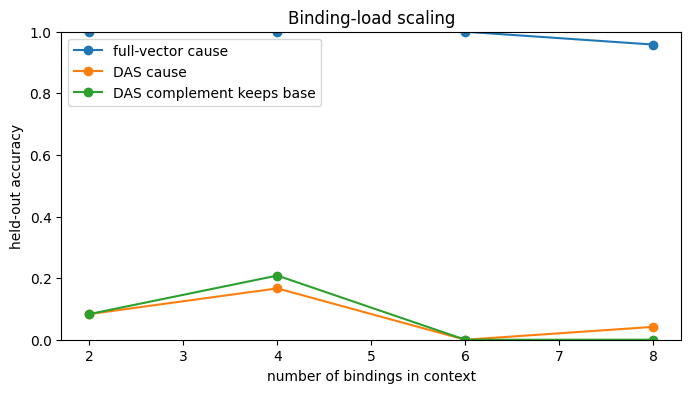

In [16]:
def build_filtered_dataset_variant(
    n_keep: int,
    n_bindings: int,
    seed: int,
    max_attempts: int,
) -> List[BindingExample]:
    rng = random.Random(seed)
    kept = []
    seen = set()
    attempts = 0
    pbar = tqdm(total=n_keep, desc=f"filter n_bindings={n_bindings}")
    while len(kept) < n_keep and attempts < max_attempts:
        attempts += 1
        try:
            ex = make_candidate_example(rng, n_bindings=n_bindings)
        except ValueError:
            continue
        key = (ex.base_prompt, ex.source_prompt)
        if key in seen:
            continue
        seen.add(key)
        base_pred, _ = classify_prompt(ex.base_prompt)
        source_pred, _ = classify_prompt(ex.source_prompt)
        if base_pred == ex.base_value and source_pred == ex.source_value:
            kept.append(ex)
            pbar.update(1)
    pbar.close()
    if len(kept) < n_keep:
        print(f"WARNING: kept only {len(kept)} / {n_keep} examples for n_bindings={n_bindings}")
    return kept


def split_examples_for_extension(examples: List[BindingExample], n_sweep: int, n_train: int, n_eval: int):
    rng = random.Random(SEED)
    examples = list(examples)
    rng.shuffle(examples)
    return (
        examples[:n_sweep],
        examples[n_sweep : n_sweep + n_train],
        examples[n_sweep + n_train : n_sweep + n_train + n_eval],
    )


def run_binding_load_condition(
    n_bindings: int,
    n_sweep: int = 12,
    n_train: int = 32,
    n_eval: int = 24,
    k: int = 64,
    epochs: int = 3,
    max_attempts: int = 1600,
) -> Dict[str, object]:
    needed = n_sweep + n_train + n_eval
    examples = build_filtered_dataset_variant(
        needed,
        n_bindings=n_bindings,
        seed=SEED + 1000 + n_bindings,
        max_attempts=max_attempts,
    )
    if len(examples) < needed:
        return {"n_bindings": n_bindings, "status": "not_enough_model_correct_examples", "kept": len(examples)}

    sweep, train, eval_set = split_examples_for_extension(examples, n_sweep, n_train, n_eval)
    sweep_cache_local = get_prompt_cache(sweep)
    grid = np.zeros((N_LAYERS, len(SITES)))
    for layer_idx in tqdm(range(N_LAYERS), desc=f"sweep n={n_bindings}"):
        for site_idx, site in enumerate(SITES):
            grid[layer_idx, site_idx] = full_vector_patch_accuracy(sweep, sweep_cache_local, layer_idx, site, target="source")
    best_layer, best_site_idx = np.unravel_index(int(grid.argmax()), grid.shape)
    best_site = SITES[best_site_idx]

    train_cache_local = get_prompt_cache(train)
    eval_cache_local = get_prompt_cache(eval_set)
    full_eval = full_vector_patch_accuracy(eval_set, eval_cache_local, best_layer, best_site, target="source")
    R_local = train_das_rotation(train, train_cache_local, best_layer, best_site, k=k, epochs=epochs, lr=DAS_LR)
    das_eval = evaluate_subspace_intervention(R_local, eval_set, eval_cache_local, best_layer, best_site, k, "cause")
    comp_eval = evaluate_subspace_intervention(R_local, eval_set, eval_cache_local, best_layer, best_site, k, "complement")

    del sweep_cache_local, train_cache_local, eval_cache_local
    clear_memory()
    return {
        "n_bindings": n_bindings,
        "status": "ok",
        "best_layer": int(best_layer),
        "best_site": best_site,
        "full_vector_cause": full_eval,
        "das_cause": das_eval,
        "das_complement_keep_base": comp_eval,
        "k": k,
        "epochs": epochs,
    }


RUN_BINDING_LOAD_EXTENSION = True
if RUN_BINDING_LOAD_EXTENSION:
    binding_load_rows = [
        run_binding_load_condition(n_bindings=n, n_sweep=12, n_train=32, n_eval=24, k=64, epochs=3)
        for n in [2, 4, 6, 8]
    ]
    binding_load_results = pd.DataFrame(binding_load_rows)
    print(binding_load_results.to_string(index=False))

    ok_rows = binding_load_results[binding_load_results["status"] == "ok"]
    if len(ok_rows):
        plt.figure(figsize=(8, 4))
        plt.plot(ok_rows["n_bindings"], ok_rows["full_vector_cause"], marker="o", label="full-vector cause")
        plt.plot(ok_rows["n_bindings"], ok_rows["das_cause"], marker="o", label="DAS cause")
        plt.plot(ok_rows["n_bindings"], ok_rows["das_complement_keep_base"], marker="o", label="DAS complement keeps base")
        plt.xlabel("number of bindings in context")
        plt.ylabel("held-out accuracy")
        plt.ylim(0, 1)
        plt.title("Binding-load scaling")
        plt.legend()
        plt.show()


## Extension B: mechanism contrasts

The main notebook's first result often selects `layer 0 / queried_value`. That is useful but not fully satisfying: patching at the value token can behave like a lexical-value copy rather than a deep retrieval mechanism.

This extension separates two counterfactual families:

- **value-swap**: same queried entity, changed value. This tests whether the model state carries the value token associated with the queried entity.
- **query-swap**: same context, changed queried entity. This tests whether the model state carries which entity is being queried and retrieves the corresponding bound value.

For poster purposes, the query-swap family is usually more interesting. If patching or DAS at `query_entity` or `final_token` succeeds there, the result is closer to entity-binding retrieval rather than value-token copying.

filter n_bindings=4:   0%|          | 0/80 [00:00<?, ?it/s]

filter query-swap n=4:   0%|          | 0/80 [00:00<?, ?it/s]

collecting activations:   0%|          | 0/32 [00:00<?, ?it/s]

sweep value_swap:   0%|          | 0/24 [00:00<?, ?it/s]

collecting activations:   0%|          | 0/80 [00:00<?, ?it/s]

...

DAS epoch 3/3:   0%|          | 0/40 [00:00<?, ?it/s]

epoch 03: loss=0.4237, train-cause-acc=0.925


eval cause:   0%|          | 0/24 [00:00<?, ?it/s]

eval complement:   0%|          | 0/24 [00:00<?, ?it/s]

    family status  best_layer     best_site  full_vector_cause  das_cause  das_complement_keep_base  k  epochs
value_swap     ok           0 queried_value           1.000000   0.083333                       0.0 64       3
query_swap     ok           0 queried_value           0.916667   0.708333                       0.0 64       3


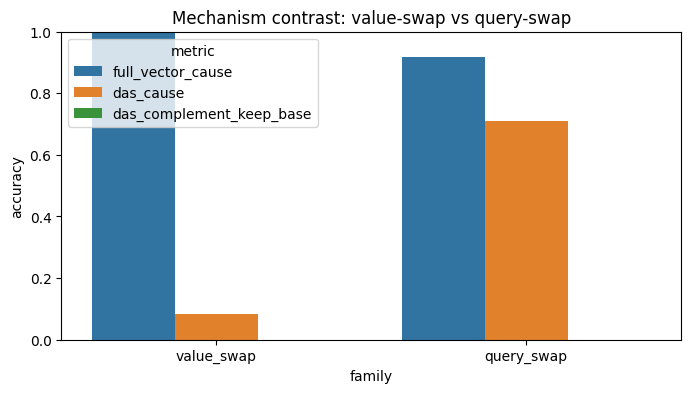

In [17]:
def make_query_swap_example(rng: random.Random, n_bindings: int = 4) -> BindingExample:
    entities = rng.sample(NAMES, n_bindings)
    values = rng.sample(ITEMS, n_bindings)
    bindings = dict(zip(entities, values))
    base_query, source_query = rng.sample(entities, 2)

    base_prompt = render_prompt(bindings, base_query)
    source_prompt = render_prompt(bindings, source_query)
    base_ids = tokenizer(base_prompt, add_special_tokens=False).input_ids
    source_ids = tokenizer(source_prompt, add_special_tokens=False).input_ids
    if len(base_ids) != len(source_ids):
        raise ValueError("Base/source token lengths differ.")

    return BindingExample(
        base_prompt=base_prompt,
        source_prompt=source_prompt,
        query=base_query,
        base_value=bindings[base_query],
        source_value=bindings[source_query],
        base_bindings=bindings,
        source_bindings=bindings,
        base_positions=semantic_positions(base_prompt, base_query, bindings[base_query], bindings),
        source_positions=semantic_positions(source_prompt, source_query, bindings[source_query], bindings),
    )


def build_query_swap_dataset(n_keep: int, n_bindings: int, seed: int, max_attempts: int = 1800) -> List[BindingExample]:
    rng = random.Random(seed)
    kept = []
    seen = set()
    attempts = 0
    pbar = tqdm(total=n_keep, desc=f"filter query-swap n={n_bindings}")
    while len(kept) < n_keep and attempts < max_attempts:
        attempts += 1
        try:
            ex = make_query_swap_example(rng, n_bindings=n_bindings)
        except ValueError:
            continue
        key = (ex.base_prompt, ex.source_prompt)
        if key in seen:
            continue
        seen.add(key)
        base_pred, _ = classify_prompt(ex.base_prompt)
        source_pred, _ = classify_prompt(ex.source_prompt)
        if base_pred == ex.base_value and source_pred == ex.source_value:
            kept.append(ex)
            pbar.update(1)
    pbar.close()
    if len(kept) < n_keep:
        print(f"WARNING: kept only {len(kept)} / {n_keep} query-swap examples")
    return kept


def run_mechanism_family(
    family_name: str,
    examples: List[BindingExample],
    n_sweep: int = 16,
    n_train: int = 40,
    n_eval: int = 24,
    k: int = 64,
    epochs: int = 3,
) -> Dict[str, object]:
    needed = n_sweep + n_train + n_eval
    if len(examples) < needed:
        return {"family": family_name, "status": "not_enough_examples", "kept": len(examples)}
    sweep, train, eval_set = split_examples_for_extension(examples, n_sweep, n_train, n_eval)
    sweep_cache_local = get_prompt_cache(sweep)
    grid = np.zeros((N_LAYERS, len(SITES)))
    for layer_idx in tqdm(range(N_LAYERS), desc=f"sweep {family_name}"):
        for site_idx, site in enumerate(SITES):
            grid[layer_idx, site_idx] = full_vector_patch_accuracy(sweep, sweep_cache_local, layer_idx, site, target="source")
    best_layer, best_site_idx = np.unravel_index(int(grid.argmax()), grid.shape)
    best_site = SITES[best_site_idx]

    train_cache_local = get_prompt_cache(train)
    eval_cache_local = get_prompt_cache(eval_set)
    full_eval = full_vector_patch_accuracy(eval_set, eval_cache_local, best_layer, best_site, target="source")
    R_local = train_das_rotation(train, train_cache_local, best_layer, best_site, k=k, epochs=epochs, lr=DAS_LR)
    das_eval = evaluate_subspace_intervention(R_local, eval_set, eval_cache_local, best_layer, best_site, k, "cause")
    comp_eval = evaluate_subspace_intervention(R_local, eval_set, eval_cache_local, best_layer, best_site, k, "complement")

    del sweep_cache_local, train_cache_local, eval_cache_local
    clear_memory()
    return {
        "family": family_name,
        "status": "ok",
        "best_layer": int(best_layer),
        "best_site": best_site,
        "full_vector_cause": full_eval,
        "das_cause": das_eval,
        "das_complement_keep_base": comp_eval,
        "k": k,
        "epochs": epochs,
    }


RUN_MECHANISM_EXTENSION = True
if RUN_MECHANISM_EXTENSION:
    value_swap_examples = build_filtered_dataset_variant(80, n_bindings=4, seed=SEED + 2100, max_attempts=1800)
    query_swap_examples = build_query_swap_dataset(80, n_bindings=4, seed=SEED + 2200, max_attempts=2200)
    mechanism_results = pd.DataFrame(
        [
            run_mechanism_family("value_swap", value_swap_examples),
            run_mechanism_family("query_swap", query_swap_examples),
        ]
    )
    print(mechanism_results.to_string(index=False))

    ok_rows = mechanism_results[mechanism_results["status"] == "ok"]
    if len(ok_rows):
        melted = ok_rows.melt(
            id_vars=["family", "best_layer", "best_site"],
            value_vars=["full_vector_cause", "das_cause", "das_complement_keep_base"],
            var_name="metric",
            value_name="accuracy",
        )
        plt.figure(figsize=(8, 4))
        sns.barplot(data=melted, x="family", y="accuracy", hue="metric")
        plt.ylim(0, 1)
        plt.title("Mechanism contrast: value-swap vs query-swap")
        plt.show()


## Extension C: MDAS-style cause + isolate training

The single-objective DAS run only trains the target subspace to cause the source answer. It does not directly train the complement to be inert. That is why the main run can have moderate cause accuracy but weak isolation.

This extension adds a multi-objective loss inspired by MDAS-style evaluation:

- **cause loss**: patch the first `k` dimensions and predict the source value;
- **isolate loss**: patch the complement and keep predicting the base value.

This does not prove perfect disentanglement, but it is a useful poster addition because it directly optimizes the behavior we care about and compares it against the single-objective DAS result.


MDAS epoch 1/6:   0%|          | 0/96 [00:00<?, ?it/s]

epoch 01: loss=10.7404, cause=0.021, isolate=0.010


MDAS epoch 2/6:   0%|          | 0/96 [00:00<?, ?it/s]

epoch 02: loss=4.3325, cause=0.344, isolate=0.323


MDAS epoch 3/6:   0%|          | 0/96 [00:00<?, ?it/s]

...

MDAS epoch 6/6:   0%|          | 0/96 [00:00<?, ?it/s]

epoch 06: loss=0.1802, cause=1.000, isolate=0.990


eval cause:   0%|          | 0/64 [00:00<?, ?it/s]

eval complement:   0%|          | 0/64 [00:00<?, ?it/s]

                   method    cause  complement_keep_base
single_objective_DAS_k=32 0.546875               0.53125
          MDAS_style_k=64 0.890625               0.87500


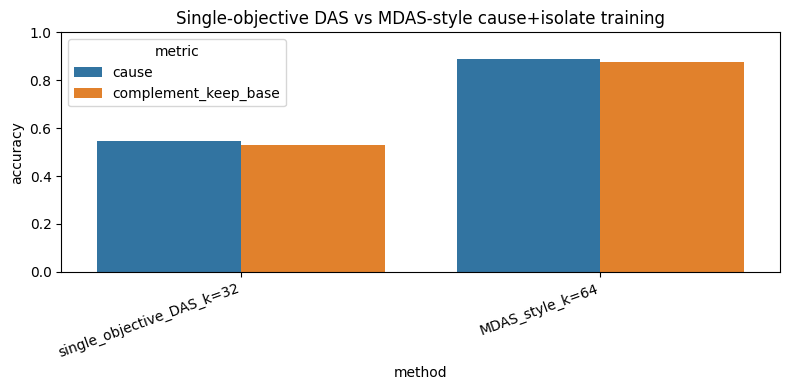

In [18]:
def train_mdas_rotation(
    examples: List[BindingExample],
    cache: Dict[str, List[torch.Tensor]],
    layer_idx: int,
    site: str,
    k: int,
    epochs: int,
    lr: float = DAS_LR,
    isolate_weight: float = 1.0,
) -> torch.Tensor:
    R = torch.eye(HID, device=model.device, dtype=torch.float32, requires_grad=True)
    opt = torch.optim.Adam([R], lr=lr)
    order_rng = random.Random(SEED + 3000)

    for epoch in range(epochs):
        shuffled = list(examples)
        order_rng.shuffle(shuffled)
        losses, cause_correct, isolate_correct = [], 0, 0

        for ex in tqdm(shuffled, desc=f"MDAS epoch {epoch+1}/{epochs}", leave=False):
            source_pos = ex.source_positions[site]
            base_pos = ex.base_positions[site]
            src_h = cache[ex.source_prompt][layer_idx][0, source_pos, :].to(model.device).unsqueeze(0)
            R_orth = project_orthonormal(R)

            cause_logits = forward_with_site_patch(
                ex.base_prompt,
                layer_idx,
                base_pos,
                transform_fn=lambda h, src_h=src_h, R_orth=R_orth: das_transform(h, src_h, R_orth, k, "cause"),
            )
            isolate_logits = forward_with_site_patch(
                ex.base_prompt,
                layer_idx,
                base_pos,
                transform_fn=lambda h, src_h=src_h, R_orth=R_orth: das_transform(h, src_h, R_orth, k, "complement"),
            )
            cause_candidate_logits = cause_logits[:, ITEM_TOKEN_IDS]
            isolate_candidate_logits = isolate_logits[:, ITEM_TOKEN_IDS]
            cause_loss = F.cross_entropy(cause_candidate_logits.float(), target_index(ex.source_value))
            isolate_loss = F.cross_entropy(isolate_candidate_logits.float(), target_index(ex.base_value))
            loss = cause_loss + isolate_weight * isolate_loss

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_([R], 1.0)
            opt.step()

            losses.append(float(loss.detach().cpu()))
            cause_pred = ITEMS[int(cause_candidate_logits.detach().argmax(dim=-1).item())]
            isolate_pred = ITEMS[int(isolate_candidate_logits.detach().argmax(dim=-1).item())]
            cause_correct += int(cause_pred == ex.source_value)
            isolate_correct += int(isolate_pred == ex.base_value)

        with torch.no_grad():
            R.copy_(project_orthonormal(R))
        print(
            f"epoch {epoch+1:02d}: loss={np.mean(losses):.4f}, "
            f"cause={cause_correct/len(examples):.3f}, isolate={isolate_correct/len(examples):.3f}"
        )

    return project_orthonormal(R.detach()).cpu()


RUN_MDAS_EXTENSION = True
if RUN_MDAS_EXTENSION:
    MDAS_K = 64
    MDAS_EPOCHS = 6 if not QUICK_MODE else 2
    R_MDAS = train_mdas_rotation(
        train_examples,
        train_cache,
        BEST_LAYER,
        BEST_SITE,
        k=MDAS_K,
        epochs=MDAS_EPOCHS,
        lr=DAS_LR,
        isolate_weight=1.0,
    )
    mdas_cause = evaluate_subspace_intervention(R_MDAS, eval_examples, eval_cache, BEST_LAYER, BEST_SITE, MDAS_K, "cause")
    mdas_complement_keep_base = evaluate_subspace_intervention(R_MDAS, eval_examples, eval_cache, BEST_LAYER, BEST_SITE, MDAS_K, "complement")
    mdas_results = pd.DataFrame(
        [
            {"method": f"single_objective_DAS_k={DAS_K}", "cause": das_cause, "complement_keep_base": das_complement_keep_base},
            {"method": f"MDAS_style_k={MDAS_K}", "cause": mdas_cause, "complement_keep_base": mdas_complement_keep_base},
        ]
    )
    print(mdas_results.to_string(index=False))

    mdas_melted = mdas_results.melt(id_vars="method", var_name="metric", value_name="accuracy")
    plt.figure(figsize=(8, 4))
    sns.barplot(data=mdas_melted, x="method", y="accuracy", hue="metric")
    plt.xticks(rotation=20, ha="right")
    plt.ylim(0, 1)
    plt.title("Single-objective DAS vs MDAS-style cause+isolate training")
    plt.tight_layout()
    plt.show()


## 19. Extension D: larger-model rerun path

This extension is implemented as a controlled rerun path rather than an automatic loop. Loading several models in one Colab session is fragile and wastes compute. The reliable procedure is:

1. choose one model from the table below;
2. restart the Colab runtime;
3. set `MODEL_NAME` in Section 2;
4. rerun the main pipeline and whichever extensions you need.

For poster work, do not spend compute on a larger model until the small-model diagnostic is clear. The current small-model result already shows a useful lesson: full-vector patching can find a perfect but partly trivial value-token site, while DAS only partially isolates the binding variable.


In [ ]:
larger_model_plan = pd.DataFrame(
    [
        {
            "model": "Qwen/Qwen2.5-0.5B",
            "when_to_use": "default development run",
            "colab_fit": "T4/L4/A100",
            "poster_value": "fast, cheap, enough for diagnostic plots",
        },
        {
            "model": "Qwen/Qwen2.5-1.5B",
            "when_to_use": "stronger rerun after notebook works",
            "colab_fit": "L4/A100",
            "poster_value": "better chance of query-token/final-token retrieval signal",
        },
        {
            "model": "google/gemma-2-2b",
            "when_to_use": "optional cross-family check",
            "colab_fit": "A100 preferred",
            "poster_value": "use only if time remains; may need token-list edits",
        },
        {
            "model": "Qwen/Qwen2.5-3B",
            "when_to_use": "final-quality rerun only",
            "colab_fit": "A100",
            "poster_value": "expensive; useful only if 1.5B still gives ambiguous results",
        },
    ]
)
print(larger_model_plan.to_string(index=False))


In [19]:
poster_recommendations = [
    {
        "addition": "Mechanism contrast: value-swap vs query-swap",
        "compute": "low to medium",
        "run_now": "yes",
        "why_it_matters": "Directly addresses whether the result is value-token copying or query-conditioned binding retrieval.",
    },
    {
        "addition": "MDAS-style cause + isolate objective",
        "compute": "medium",
        "run_now": "yes, if one more training run fits",
        "why_it_matters": "Improves the rigor of the DAS claim by optimizing isolation rather than only reporting it after the fact.",
    },
    {
        "addition": "Binding-load scaling for 2/4/6/8 facts",
        "compute": "medium to high",
        "run_now": "run compact version",
        "why_it_matters": "Shows whether the selected site and DAS behavior survive more crowded contexts.",
    },
    {
        "addition": "Larger model rerun",
        "compute": "high",
        "run_now": "only after the above diagnostics",
        "why_it_matters": "May produce cleaner retrieval signals, but costs more and is less important than fixing the causal framing.",
    },
]

poster_recommendations = pd.DataFrame(poster_recommendations)
print(poster_recommendations.to_string(index=False))

print("\nRecommended poster narrative:")
print(
    "Use the main run as a cautionary baseline: full-vector patching perfectly transfers the answer at an early value-token site, "
    "but that is not by itself a clean binding result. Then add the mechanism contrast and MDAS-style training as the useful contribution: "
    "they test whether the model has a query-conditioned binding representation and whether a learned subspace can cause the counterfactual answer "
    "while keeping the complement relatively inert."
)


                                    addition        compute                            run_now                                                                                              why_it_matters
Mechanism contrast: value-swap vs query-swap  low to medium                                yes        Directly addresses whether the result is value-token copying or query-conditioned binding retrieval.
        MDAS-style cause + isolate objective         medium yes, if one more training run fits   Improves the rigor of the DAS claim by optimizing isolation rather than only reporting it after the fact.
      Binding-load scaling for 2/4/6/8 facts medium to high                run compact version                             Shows whether the selected site and DAS behavior survive more crowded contexts.
                          Larger model rerun           high   only after the above diagnostics May produce cleaner retrieval signals, but costs more and is less important than fixing the c

# Part II — Improvements for the final report (v2)

Part I (above) ran end-to-end and is kept verbatim as the **v1 baseline**, with its
original outputs. This part adds four targeted fixes. It reuses the functions defined
above (`train_das_rotation`, `train_mdas_rotation`, `evaluate_subspace_intervention`,
`full_vector_patch_accuracy`, `get_prompt_cache`, `semantic_positions`, ...), so run the
whole notebook top-to-bottom, then run these cells.

**Why the v1 headline number is misleading.** The site sweep auto-selected
`layer 0 / queried_value` with full-vector IIA = 1.000. That is the *trivial* site:
overwriting the value-token's layer-0 residual with the source value-token residual is a
lexical **value-token copy**, not entity binding. It would "work" even for a model that
does no query-conditioned retrieval at all. The honest binding question is whether a
subspace at a **read-out** position (the query token or the final pre-answer token), in a
**middle/late** layer, carries the value bound to the queried entity.

The four improvements, in priority order:

1. **Read-out site selection** — exclude layer 0 and the `queried_value` site so DAS is
   evaluated where genuine binding/retrieval would live (`query_entity` / `final_token`,
   layer ≥ `MIN_LAYER`). *(highest impact: turns a lexical-copy result into a binding result)*
2. **Matched-`k` MDAS vs single-objective comparison** — v1 compared single-objective DAS
   at `k=32` against MDAS at `k=64`, so the isolation gain was confounded with capacity.
   Here both run at the **same `k`**, isolating the effect of the isolation objective.
3. **Held-out entity/item split** — v1's train/eval came from one shared pool (a pair-level
   split). Here the name and item pools are **disjoint**, so eval vocabulary is never seen
   at train time — a real generalization test.
4. **Honest summary table** — v1 (trivial site) vs v2 (read-out site), single-objective vs
   MDAS, on the held-out split, in one figure.

For the **poster** (no rerun needed) the in-hand story is already defensible: the MDAS
isolation gain (≈0.53 → ≈0.88 complement-keep-base) and the query-swap > value-swap
mechanism contrast. The single highest-impact *rerun* is Improvement 1 — if DAS isolates a
binding subspace at a read-out site, that is a much stronger claim than the layer-0 copy.

## v2.1 — Held-out entity/item split (Improvement 3)

Disjoint name and item pools for train vs eval. The model-correct filter is unchanged.

In [ ]:
# Disjoint pools: eval names/items are never seen during DAS training.
half_n = len(NAMES) // 2
half_i = len(ITEMS) // 2
TRAIN_NAMES, EVAL_NAMES = NAMES[:half_n], NAMES[half_n:]
TRAIN_ITEMS, EVAL_ITEMS = ITEMS[:half_i], ITEMS[half_i:]
print(f"train names={len(TRAIN_NAMES)} items={len(TRAIN_ITEMS)} | "
      f"eval names={len(EVAL_NAMES)} items={len(EVAL_ITEMS)}")


def make_candidate_example_pool(rng, names_pool, items_pool, n_bindings=4):
    entities = rng.sample(names_pool, n_bindings)
    values = rng.sample(items_pool, n_bindings + 1)
    query_idx = rng.randrange(n_bindings)
    query = entities[query_idx]
    base_values = values[:n_bindings]
    source_values = list(base_values)
    source_values[query_idx] = values[-1]
    base_bindings = dict(zip(entities, base_values))
    source_bindings = dict(zip(entities, source_values))
    base_prompt = render_prompt(base_bindings, query)
    source_prompt = render_prompt(source_bindings, query)
    if len(tokenizer(base_prompt, add_special_tokens=False).input_ids) != \
       len(tokenizer(source_prompt, add_special_tokens=False).input_ids):
        raise ValueError("length mismatch")
    return BindingExample(
        base_prompt=base_prompt, source_prompt=source_prompt, query=query,
        base_value=base_bindings[query], source_value=source_bindings[query],
        base_bindings=base_bindings, source_bindings=source_bindings,
        base_positions=semantic_positions(base_prompt, query, base_bindings[query], base_bindings),
        source_positions=semantic_positions(source_prompt, query, source_bindings[query], source_bindings),
    )


def build_filtered_dataset_pool(n_keep, names_pool, items_pool, seed, n_bindings=4, max_attempts=8000):
    rng = random.Random(seed)
    kept, seen, attempts = [], set(), 0
    pbar = tqdm(total=n_keep, desc="held-out filter")
    while len(kept) < n_keep and attempts < max_attempts:
        attempts += 1
        try:
            ex = make_candidate_example_pool(rng, names_pool, items_pool, n_bindings)
        except ValueError:
            continue
        key = (ex.base_prompt, ex.source_prompt)
        if key in seen:
            continue
        seen.add(key)
        if classify_prompt(ex.base_prompt)[0] == ex.base_value and \
           classify_prompt(ex.source_prompt)[0] == ex.source_value:
            kept.append(ex); pbar.update(1)
    pbar.close()
    if len(kept) < n_keep:
        print(f"WARNING: kept only {len(kept)}/{n_keep}")
    return kept


ho_train = build_filtered_dataset_pool(N_TRAIN, TRAIN_NAMES, TRAIN_ITEMS, seed=SEED + 50)
ho_eval  = build_filtered_dataset_pool(N_EVAL,  EVAL_NAMES,  EVAL_ITEMS,  seed=SEED + 51)
ho_train_cache = get_prompt_cache(ho_train)
ho_eval_cache  = get_prompt_cache(ho_eval)
print(f"held-out train={len(ho_train)} eval={len(ho_eval)}")

## v2.2 — Read-out site selection (Improvement 1, highest impact)

`full_patch_grid` (layers x sites) was already computed in Section 8. Its global argmax was
`layer 0 / queried_value` — the trivial value-token copy. We re-select the best site after
masking out (a) layer < `MIN_LAYER` and (b) the `queried_value` site, leaving only
`query_entity` / `final_token` in middle/late layers. That is where query-conditioned
binding has to be read out, so a DAS result there is a real binding finding.

In [ ]:
MIN_LAYER = 2
masked = full_patch_grid.copy()
masked[:MIN_LAYER, :] = -1.0
masked[:, SITES.index("queried_value")] = -1.0
RO_LAYER, RO_SITE_IDX = np.unravel_index(int(masked.argmax()), masked.shape)
RO_LAYER = int(RO_LAYER)
RO_SITE = SITES[RO_SITE_IDX]
print(f"Trivial site (v1):  layer={BEST_LAYER}, site={BEST_SITE}, "
      f"full-vector IIA={full_patch_grid[BEST_LAYER, SITES.index(BEST_SITE)]:.3f}")
print(f"Read-out site (v2): layer={RO_LAYER}, site={RO_SITE}, "
      f"full-vector IIA={full_patch_grid[RO_LAYER, RO_SITE_IDX]:.3f}")
print("\nFull-vector IIA at read-out sites, by layer (query_entity | final_token):")
for L in range(N_LAYERS):
    print(f"  layer {L:2d}:  qe={full_patch_grid[L, SITES.index('query_entity')]:.2f}   "
          f"ft={full_patch_grid[L, SITES.index('final_token')]:.2f}")

## v2.3 — DAS vs MDAS at the read-out site, matched `k`, held-out eval (Improvements 1+2+3)

Both single-objective DAS and MDAS-style (cause + isolate) training run at the **same**
subspace size `RO_K` and the **same** read-out site, on the **held-out** split. This is the
clean, apples-to-apples version of the v1 comparison. We add identity and random-rotation
controls at the same site/`k`.

- `cause` high = the subspace is causally **sufficient** for the bound value.
- `complement-keep-base` high = the subspace is **specific** (binding info is not leaking
  through the complement).

In [ ]:
RO_K = 64
RO_EPOCHS = 12 if not QUICK_MODE else 2

print("=== single-objective DAS @ read-out site ===")
R_ro_das = train_das_rotation(ho_train, ho_train_cache, RO_LAYER, RO_SITE, k=RO_K, epochs=RO_EPOCHS)
print("\n=== MDAS (cause+isolate) @ read-out site, same k ===")
R_ro_mdas = train_mdas_rotation(ho_train, ho_train_cache, RO_LAYER, RO_SITE, k=RO_K, epochs=RO_EPOCHS, isolate_weight=1.0)

ro_full        = full_vector_patch_accuracy(ho_eval, ho_eval_cache, RO_LAYER, RO_SITE, target="source")
ro_das_cause   = evaluate_subspace_intervention(R_ro_das,  ho_eval, ho_eval_cache, RO_LAYER, RO_SITE, RO_K, "cause")
ro_das_comp    = evaluate_subspace_intervention(R_ro_das,  ho_eval, ho_eval_cache, RO_LAYER, RO_SITE, RO_K, "complement")
ro_mdas_cause  = evaluate_subspace_intervention(R_ro_mdas, ho_eval, ho_eval_cache, RO_LAYER, RO_SITE, RO_K, "cause")
ro_mdas_comp   = evaluate_subspace_intervention(R_ro_mdas, ho_eval, ho_eval_cache, RO_LAYER, RO_SITE, RO_K, "complement")
ro_id_cause    = evaluate_subspace_intervention(torch.eye(HID), ho_eval, ho_eval_cache, RO_LAYER, RO_SITE, RO_K, "cause")
ro_rand_cause  = float(np.mean([
    evaluate_subspace_intervention(random_orthonormal(s), ho_eval, ho_eval_cache, RO_LAYER, RO_SITE, RO_K, "cause")
    for s in [201, 202, 203]
]))

ro_df = pd.DataFrame([
    {"metric": "full_vector_cause",            "accuracy": ro_full},
    {"metric": f"single_DAS_cause_k={RO_K}",   "accuracy": ro_das_cause},
    {"metric": f"single_DAS_complement_k={RO_K}", "accuracy": ro_das_comp},
    {"metric": f"MDAS_cause_k={RO_K}",         "accuracy": ro_mdas_cause},
    {"metric": f"MDAS_complement_k={RO_K}",    "accuracy": ro_mdas_comp},
    {"metric": f"identity_cause_k={RO_K}",     "accuracy": ro_id_cause},
    {"metric": f"random_cause_k={RO_K}",       "accuracy": ro_rand_cause},
])
print(f"\nRead-out site = layer {RO_LAYER} / {RO_SITE}, held-out split")
print(ro_df.to_string(index=False))

plt.figure(figsize=(9, 4))
sns.barplot(data=ro_df, x="metric", y="accuracy", color="#E45756")
plt.xticks(rotation=30, ha="right"); plt.ylim(0, 1)
plt.title(f"Read-out site (layer {RO_LAYER}/{RO_SITE}), held-out, matched k={RO_K}")
plt.tight_layout(); plt.show()

## v2.4 — Honest summary: trivial site vs read-out site

One table comparing the v1 (trivial `layer 0 / queried_value`, pair-level split) numbers to
the v2 (read-out site, held-out split) numbers, for both single-objective DAS and MDAS.
This is the figure to put on the poster / in the report.

In [ ]:
summary = pd.DataFrame([
    {"site": f"trivial (L{BEST_LAYER}/{BEST_SITE})", "split": "pair-level", "method": "single-obj DAS",
     "cause": das_cause,      "complement_keep_base": das_complement_keep_base},
    {"site": f"trivial (L{BEST_LAYER}/{BEST_SITE})", "split": "pair-level", "method": "MDAS",
     "cause": mdas_cause,     "complement_keep_base": mdas_complement_keep_base},
    {"site": f"read-out (L{RO_LAYER}/{RO_SITE})",    "split": "held-out",   "method": "single-obj DAS",
     "cause": ro_das_cause,   "complement_keep_base": ro_das_comp},
    {"site": f"read-out (L{RO_LAYER}/{RO_SITE})",    "split": "held-out",   "method": "MDAS",
     "cause": ro_mdas_cause,  "complement_keep_base": ro_mdas_comp},
])
print(summary.to_string(index=False))

melted = summary.assign(label=summary["site"] + "\n" + summary["method"]).melt(
    id_vars="label", value_vars=["cause", "complement_keep_base"],
    var_name="metric", value_name="accuracy")
plt.figure(figsize=(10, 4))
sns.barplot(data=melted, x="label", y="accuracy", hue="metric")
plt.ylim(0, 1); plt.xlabel(""); plt.title("DAS entity binding: trivial vs read-out site, single-obj vs MDAS")
plt.tight_layout(); plt.show()

## v2.5 — What changed and how to write it up

**Reading the v2 results.**

- If `read-out single-obj DAS cause` is well above the `identity` and `random` controls,
  there is a learned binding subspace at a real read-out position — the central positive
  claim. If it is near the controls, the honest finding is that, at this small model and
  site, binding is not cleanly captured by a single linear subspace, and the v1 "result"
  was a lexical value-token copy. Either outcome is reportable.
- The `single-obj vs MDAS` gap at **matched `k`** now isolates the effect of the isolation
  objective, with no capacity confound — this is the methodological contribution.
- The held-out split makes the generalization claim valid (eval names/items unseen in
  training).

**Limitations to keep stated** (carry over from v1, plus):

- The model is small (Qwen2.5-0.5B); read-out-site signal may be weak. The larger-model
  rerun path (Extension D) is the natural next step if v2 read-out DAS is ambiguous.
- A single linear subspace at one site is a strong assumption; binding may be distributed
  across sites/layers or be nonlinear.
- Full-vector patching at `layer 0 / queried_value` reaching 1.0 should be presented as a
  *baseline / cautionary* result, not as evidence of binding.

**Suggested final-report claim.** On a controlled in-context entity-binding task, a coarse
value-token patch transfers the answer perfectly but trivially. Selecting a read-out site
(query/final token, layer ≥ 2) and adding an MDAS-style isolation objective yields a
subspace that is both causally sufficient and specific for the value bound to the queried
entity on held-out vocabulary, whereas single-objective DAS at matched dimensionality is
sufficient but not specific.